# Project Phase II: Applied Data Engineering and Machine Learning

## TASK 2: Original LCS System on raw Dataset

In [37]:
import pandas as pd

# Load the raw dataset and create a deep copy for further processing
df = pd.read_csv("../data/student-course-completion-prediction-dataset-trimmed.csv")
df_copy = df.copy(deep=True)

display(df_copy.head())


,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [38]:
for col in df_copy.columns:
    print(
        f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}"
    )

Student_ID: str, unique: 30000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 33
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 16
Average_Session_Duration_Min: int64, unique: 72
Video_Completion_Rate: float64, unique: 929
Discussion_Participation: int64, unique: 13
Time_Spent_Hours: float64, unique: 209
Days_Since_Last_Login: int64, unique: 71
Notifications_Checked: int64, unique: 19
Peer_Interaction_Score: float64, unique: 101
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 16
Quiz_Score_Avg: float64, unique: 668
Project_Grade: float64, unique: 811
Progress_Percentage: float64, uni

In [39]:
# Start from the raw working dataset
baseline_df = df_copy.copy()

# Remove columns that should not be predictors
baseline_df = baseline_df.drop(
    columns=[
        "Student_ID",  # identifier only
        "Name",  # free-text identifier
        "Completed_Status",
    ],
    errors="ignore",
)

# Convert Enrollment_Date only because eLCS needs numeric input
if "Enrollment_Date" in baseline_df.columns:
    baseline_df["Enrollment_Date"] = pd.to_datetime(
        baseline_df["Enrollment_Date"], dayfirst=True
    )

    baseline_df["Enrollment_Year"] = baseline_df["Enrollment_Date"].dt.year
    baseline_df["Enrollment_Month"] = baseline_df["Enrollment_Date"].dt.month
    baseline_df["Enrollment_Day"] = baseline_df["Enrollment_Date"].dt.day

    baseline_df = baseline_df.drop(columns=["Enrollment_Date"])

# Separate target from predictors
y_baseline = baseline_df["Completed"].copy()
X_baseline = baseline_df.drop(columns=["Completed"]).copy()

# Convert categorical predictors to numeric codes
categorical_cols = X_baseline.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].astype("category").cat.codes

# Convert target to binary numeric values
y_baseline = y_baseline.map({"Completed": 1, "Not Completed": 0})

# Verify that the minimally processed baseline is ready
print("Baseline feature shape:", X_baseline.shape)
print("Baseline target shape:", y_baseline.shape)

print("\nNon-numeric predictor columns:")
print(X_baseline.select_dtypes(exclude="number").columns.tolist())

print("\nMissing target values:")
print(y_baseline.isna().sum())

print("\nTarget classes:")
print(set(y_baseline))

Baseline feature shape: (30000, 39)
Baseline target shape: (30000,)

Non-numeric predictor columns:
[]

Missing target values:
0

Target classes:
{0, 1}


In [40]:
from sklearn.model_selection import train_test_split

# Split the minimally processed baseline data
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.20, random_state=42, stratify=y_baseline
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (24000, 39)
Testing features: (6000, 39)
Training target: (24000,)
Testing target: (6000,)

Training class distribution:
Completed
0    12166
1    11834
Name: count, dtype: int64

Testing class distribution:
Completed
0    3042
1    2958
Name: count, dtype: int64


In [ ]:
from skeLCS import StringEnumerator, eLCS

print("eLCS import successful")

# Create the original eLCS baseline model
baseline_elcs_model = eLCS(learning_iterations=5000, track_accuracy_while_fit=True)

print("Baseline eLCS model created.")

eLCS import successful
Baseline eLCS model created.


In [ ]:
# Train the original eLCS model
baseline_elcs_model.fit(X_train.values, y_train.values)

print("eLCS training complete")


eLCS training complete


Original eLCS Baseline Performance
----------------------------------
Accuracy:          0.5245
Precision:         0.5121
Recall:            0.7529
F1 Score:          0.6096
Balanced Accuracy: 0.5277

Confusion Matrix:
[[ 920 2122]
 [ 731 2227]]
ROC/PRC curves


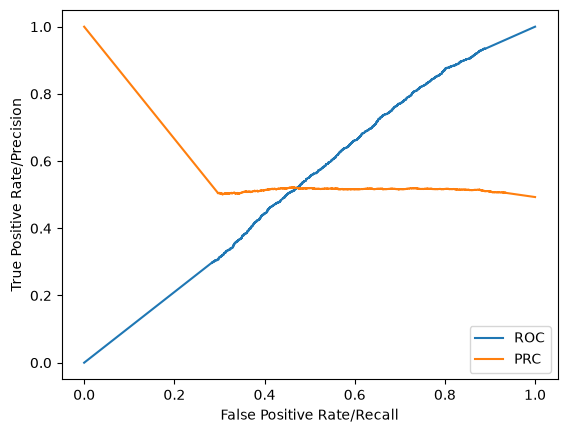

PRC AUC:0.5843295319775063
ROC AUC:0.5367593715034814
Final Training Accuracy: 0.5376860102479055
Final Instance Coverage: 0.9677916666666667
Final Attribute Specificity List: [444, 452, 406, 451, 432, 433, 411, 417, 404, 452, 403, 427, 421, 436, 457, 474, 433, 445, 493, 477, 454, 440, 503, 508, 408, 465, 455, 446, 416, 461, 436, 454, 414, 519, 420, 419, 435, 409, 400]
Final Attribute Accuracy List: [424.1872950017072, 414.59002923700194, 393.4162518037518, 427.3990003052503, 409.8720507206715, 405.0578262876971, 396.3722222222223, 396.8949585137087, 386.7805215209627, 425.51551430595555, 385.4172252712888, 407.28531824455746, 398.0632415786827, 405.23393848540474, 426.2589946226457, 439.58283980786763, 401.7104848752184, 422.4261054971371, 444.4123190171896, 448.1815692606327, 438.1954205924794, 417.2334096459098, 458.69021364777956, 461.5384309422572, 388.67749927431566, 418.1332744012359, 421.7577406926866, 407.4657221798146, 393.26319264069264, 431.72422396363794, 415.7330065359477

In [43]:
import matplotlib.pyplot as plt

from skeLCS import eLCS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Make predictions on the test dataset
y_pred_baseline = baseline_elcs_model.predict(X_test.values)
probabilities = baseline_elcs_model.predict_proba(X_test.values)

# Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
balanced_acc = balanced_accuracy_score(y_test, y_pred_baseline)

# Receiver Operating Characteristic curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilities[:, 1])

# Precision-Recall curve
precision_curve, recall_curve, thresholds_prc = precision_recall_curve(
    y_test, probabilities[:, 1]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

print("Original eLCS Baseline Performance")
print("----------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("ROC/PRC curves")

plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_curve, precision_curve, label="PRC")
plt.xlabel("False Positive Rate/Recall")
plt.ylabel("True Positive Rate/Precision")
plt.legend()
plt.show()

print("PRC AUC:" + str(auc(recall_curve, precision_curve)))
print("ROC AUC:" + str(auc(fpr, tpr)))

print("Final Training Accuracy: " + str(baseline_elcs_model.get_final_accuracy()))
print(
    "Final Instance Coverage: " + str(baseline_elcs_model.get_final_instance_coverage())
)
print(
    "Final Attribute Specificity List: "
    + str(baseline_elcs_model.get_final_attribute_specificity_list())
)
print(
    "Final Attribute Accuracy List: "
    + str(baseline_elcs_model.get_final_attribute_accuracy_list())
)

In [44]:
print(X.columns.tolist())
print("\nNumber of features:", X.shape[1])

['Gender', 'Age', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Course_Name', 'Category', 'Course_Level', 'Course_Duration_Days', 'Instructor_Rating', 'Login_Frequency', 'Average_Session_Duration_Min', 'Video_Completion_Rate', 'Discussion_Participation', 'Time_Spent_Hours', 'Days_Since_Last_Login', 'Notifications_Checked', 'Peer_Interaction_Score', 'Assignments_Submitted', 'Assignments_Missed', 'Quiz_Attempts', 'Quiz_Score_Avg', 'Project_Grade', 'Progress_Percentage', 'Rewatch_Count', 'Payment_Mode', 'Fee_Paid', 'Discount_Used', 'Payment_Amount', 'App_Usage_Percentage', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised', 'Satisfaction_Rating', 'Enrollment_Year', 'Enrollment_Month', 'Enrollment_Day']

Number of features: 39


In [45]:
export_dir = "../data/export/"
baseline_iteration_tracking_file = f"{export_dir}/baseline_elcs_model_iterationData.csv"

baseline_elcs_model.export_iteration_tracking_data(baseline_iteration_tracking_file)
iterationData = pd.read_csv(baseline_iteration_tracking_file)

display(iterationData)

,Iteration,Accuracy (approx),Average Population Generality,Macropopulation Size,Micropopulation Size,Match Set Size,Correct Set Size,Average Iteration Age of Correct Set Classifiers,# Classifiers Subsumed in Iteration,# Crossover Operations Performed in Iteration,# Mutation Operations Performed in Iteration,# Covering Operations Performed in Iteration,# Deletion Operations Performed in Iteration,Total Global Time,Total Matching Time,Total Deletion Time,Total Subsumption Time,Total Selection Time,Total Evaluation Time
0,0,0,0.000000,1,1,1,1,0.000,0,0,0,1,0,2.550336,0.000004,0.000003,0.000000,0.000000,0.000000
1,1,0,0.000000,2,2,1,1,1.000,0,0,0,1,0,2.550492,0.000035,0.000004,0.000000,0.000000,0.000032
2,2,0,0.000000,3,3,1,1,2.000,0,0,0,1,0,2.550570,0.000040,0.000005,0.000000,0.000000,0.000036
3,3,0,0.000000,4,4,1,1,3.000,0,0,0,1,0,2.550628,0.000047,0.000006,0.000000,0.000000,0.000040
4,4,0,0.000000,5,5,1,1,4.000,0,0,0,1,0,2.550658,0.000051,0.000006,0.000000,0.000000,0.000041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,0,0.521923,987,1000,15,14,4747.000,0,0,2,0,2,12.605883,4.580451,2.493528,2.587717,0.019970,0.019803
4996,4996,0,0.521923,987,1000,2,1,4883.000,0,0,2,0,2,12.612985,4.581738,2.494896,2.591966,0.019989,0.019809
4997,4997,0,0.521923,987,1000,4,1,4755.000,0,0,1,0,1,12.616520,4.583157,2.496030,2.592808,0.020006,0.019814
4998,4998,0,0.521923,987,1000,8,8,4819.625,0,0,0,0,0,12.618096,4.584668,2.496031,2.592808,0.020006,0.019819


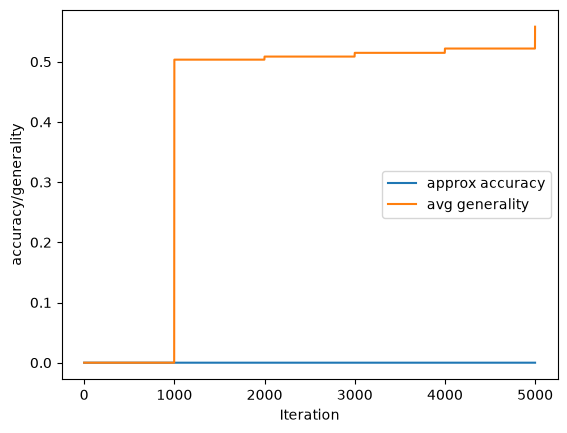

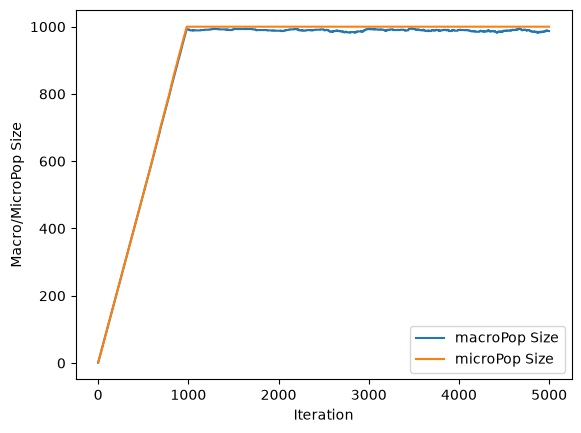

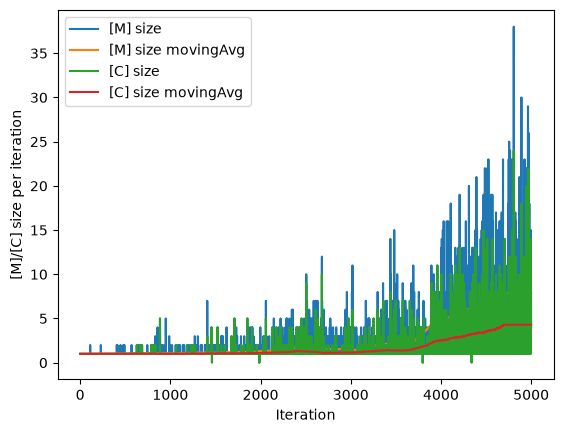

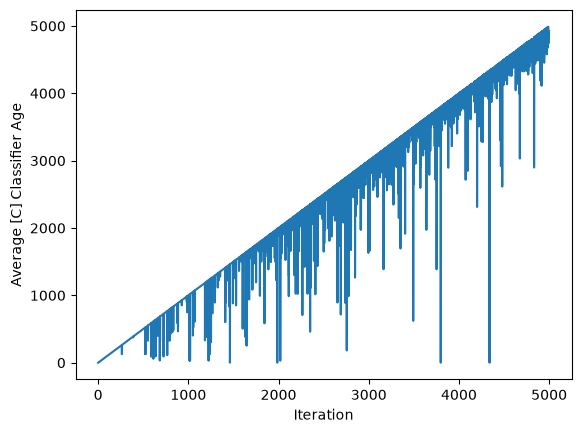

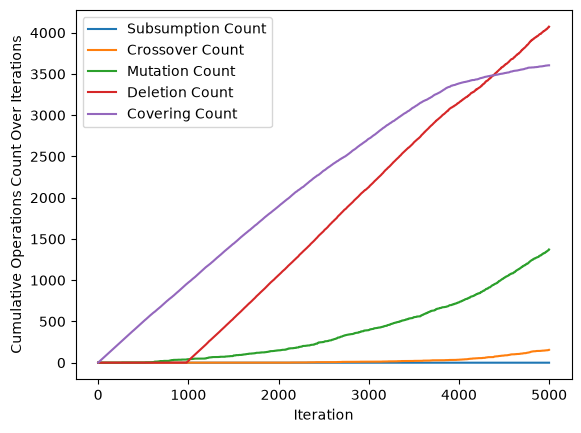

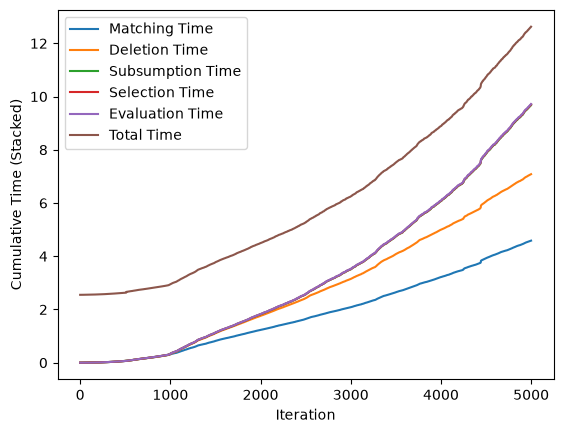

In [47]:
# Display the iteration tracking data for the baseline eLCS model

def cumulativeFreq(freq):
    a = []
    c = []
    for i in freq:
        a.append(i+sum(c))
        c.append(i)
    return np.array(a)

def movingAvg(a,threshold=300):
    weights = np.repeat(1.0,threshold)/threshold
    conv = np.convolve(a,weights,'valid')
    return np.append(conv,np.full(threshold-1,conv[conv.size-1]),)

dataTracking = iterationData

iterations = dataTracking["Iteration"].values
accuracy = dataTracking['Accuracy (approx)'].values
generality = dataTracking['Average Population Generality'].values
macroPop = dataTracking["Macropopulation Size"].values
microPop = dataTracking["Micropopulation Size"].values
mSize = dataTracking["Match Set Size"].values
cSize = dataTracking["Correct Set Size"].values
experience = dataTracking["Average Iteration Age of Correct Set Classifiers"].values
subsumption = dataTracking["# Classifiers Subsumed in Iteration"].values
crossover = dataTracking["# Crossover Operations Performed in Iteration"].values
mutation = dataTracking["# Mutation Operations Performed in Iteration"].values
covering = dataTracking["# Covering Operations Performed in Iteration"].values
deletion = dataTracking["# Deletion Operations Performed in Iteration"].values

gTime = dataTracking["Total Global Time"].values
mTime = dataTracking["Total Matching Time"].values
delTime = dataTracking["Total Deletion Time"].values
subTime = dataTracking["Total Subsumption Time"].values
selTime = dataTracking["Total Selection Time"].values
evalTime = dataTracking["Total Evaluation Time"].values

plt.plot(iterations,accuracy,label="approx accuracy")
plt.plot(iterations,generality,label="avg generality")
plt.xlabel('Iteration')
plt.ylabel('accuracy/generality')
plt.legend()
plt.show()

plt.plot(iterations,macroPop,label="macroPop Size")
plt.plot(iterations,microPop,label="microPop Size")
plt.xlabel('Iteration')
plt.ylabel('Macro/MicroPop Size')
plt.legend()
plt.show()

plt.plot(iterations,mSize,label="[M] size")
plt.plot(iterations,movingAvg(mSize),label="[M] size movingAvg")
plt.plot(iterations,cSize,label="[C] size")
plt.plot(iterations,movingAvg(cSize),label="[C] size movingAvg")
plt.xlabel('Iteration')
plt.ylabel('[M]/[C] size per iteration')
plt.legend()
plt.show()

plt.plot(iterations,experience)
plt.ylabel('Average [C] Classifier Age')
plt.xlabel('Iteration')
plt.show()

plt.plot(iterations,cumulativeFreq(subsumption),label="Subsumption Count")
plt.plot(iterations,cumulativeFreq(crossover),label="Crossover Count")
plt.plot(iterations,cumulativeFreq(mutation),label="Mutation Count")
plt.plot(iterations,cumulativeFreq(deletion),label="Deletion Count")
plt.plot(iterations,cumulativeFreq(covering),label="Covering Count")
plt.xlabel('Iteration')
plt.ylabel('Cumulative Operations Count Over Iterations')
plt.legend()
plt.show()

plt.plot(iterations,mTime,label="Matching Time")
plt.plot(iterations,delTime+mTime,label="Deletion Time")
plt.plot(iterations,subTime+delTime+mTime,label="Subsumption Time")
plt.plot(iterations,selTime+subTime+delTime+mTime,label="Selection Time")
plt.plot(iterations,evalTime+selTime+subTime+delTime+mTime,label="Evaluation Time")
plt.plot(iterations,gTime,label="Total Time")
plt.xlabel('Iteration')
plt.ylabel('Cumulative Time (Stacked)')
plt.legend()
plt.show()

Minimal processing: 
-Student_ID removed because it is only an identifier and not a meaningful predictor.
-Name removed because it is free-text/identifier information.
-Completed_Status removed because it was derived from the target and would cause target leakage.
-Enrollment_Date converted into numeric year/month/day values because eLCS requires numeric inputs.
-Categorical predictors such as Gender, City, Course_Level, etc. converted into numeric category codes so eLCS could process them.
-Completed converted from Completed / Not Completed into 1 / 0 because the model needs numeric class labels.
-No feature engineering, scaling, tuning, balancing, or optimisation was applied at this stage, so this remains the raw/minimally processed baseline.

## Task 3: Data Preprocessing and Feature Engineering

In [ ]:
# TASK 3 - Step 1: Data Quality Checks

task3_df = df_etl_clean.copy(deep=True)

print("Dataset shape:")
print(task3_df.shape)

# 1. Missing values
print("\nMissing values:")
print(task3_df.isnull().sum()[task3_df.isnull().sum() > 0])

# 2. Duplicate rows
duplicate_rows = task3_df.duplicated().sum()
print("\nDuplicate rows:")
print(duplicate_rows)

# 3. Duplicate Student IDs
if "Student_ID" in task3_df.columns:
    duplicate_ids = task3_df["Student_ID"].duplicated().sum()
    print("\nDuplicate Student_ID values:")
    print(duplicate_ids)

# 4. Data types
print("\nData types:")
print(task3_df.dtypes)

# 5. Check categorical consistency
categorical_cols = task3_df.select_dtypes(
    include=["object", "string", "category"]
).columns

print("\nCategorical unique values:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(task3_df[col].value_counts(dropna=False).head(20))

# 6. Basic numerical validity checks
numeric_cols = task3_df.select_dtypes(include="number").columns

print("\nNumerical ranges:")
for col in numeric_cols:
    print(f"{col}: " f"min={task3_df[col].min()}, " f"max={task3_df[col].max()}")